In [44]:
import os
import sys

import pandas as pd
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from sklearnex import patch_sklearn
patch_sklearn()

import config as cfg

TARGET = 'daylight-2016-01-06T00_00_00Z'
IMG_IDX = 1000

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


# Clustering on full dataset

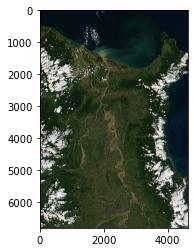

In [45]:
path= r'C:\Users\paolo\OneDrive\Desktop\Projects\laguna-philippines-mapping-fisheries\src\data\Satellite Images\Satellite Images\Day Time\daylight-30m-per-pixel\2016\daylight-2016-01-06T00_00_00Z.tiff'

full_img = cv.imread(path)
full_img = cv.cvtColor(full_img, cv.COLOR_BGR2RGB)

plt.imshow(full_img)
plt.show()

In [46]:
full_img.shape

(6791, 4621, 3)

In [47]:
full_pixels = pd.DataFrame(full_img.reshape(full_img.shape[0] * full_img.shape[1], 3), columns=['R', 'G', 'B'])
full_pixels

,R,G,B
0,5,14,23
1,5,14,23
2,5,14,23
3,5,14,23
4,5,14,23
...,...,...,...
31381206,94,111,101
31381207,94,111,101
31381208,94,111,101
31381209,94,111,101


Done Clustering 2 clusters...
Done Clustering 3 clusters...
Done Clustering 4 clusters...
Done Clustering 5 clusters...
Done Clustering 6 clusters...
Done Clustering 7 clusters...
Done Clustering 8 clusters...
Done Clustering 9 clusters...


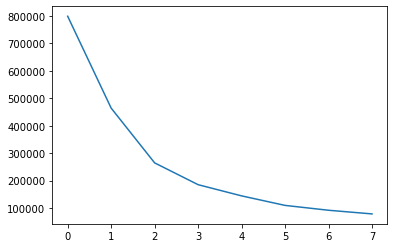

In [6]:
from sklearn.cluster import KMeans

inertias = []
n = 10
for i in range(2, n):
    temp = full_pixels.copy()
    for col in temp.columns:
        temp[col] = temp[col] / 255.
    model = KMeans(n_clusters=i)
    model.fit(temp)
    temp['clusters'] = model.predict(temp)
    inertias.append(model.inertia_)
    print(f'Done Clustering {i} clusters...')

plt.plot(inertias)
plt.show()

In [54]:
temp = full_pixels.copy()
for col in temp.columns:
    temp[col] = temp[col] / 255.
model = KMeans(n_clusters=7)
model.fit(temp)
temp['clusters'] = model.predict(temp)
inertias.append(model.inertia_)
print(f'Done Clustering {i} clusters...')

Done Clustering 5 clusters...


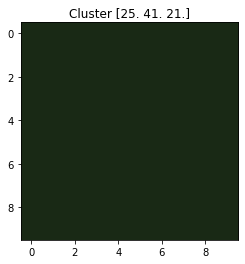

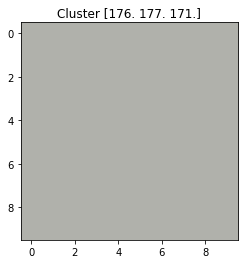

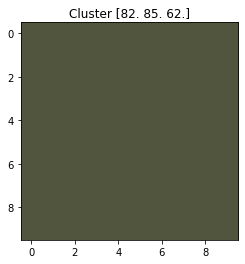

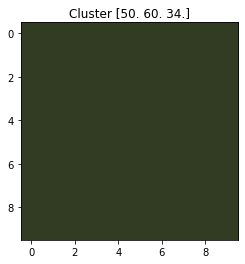

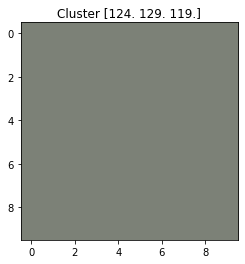

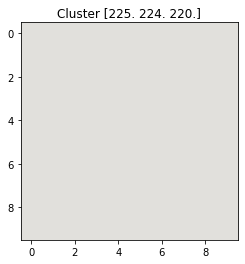

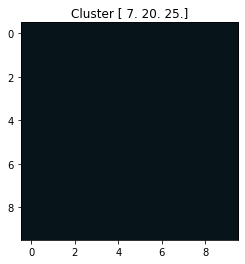

In [55]:
colors = temp.groupby('clusters').mean()

for i, colorvals in colors.iterrows():
    pixel = np.round(colorvals.values * 255.)
    color_img = np.array([pixel for i in range(0, 100)]).reshape(10, 10, 3).astype(int)
    plt.imshow(color_img)
    plt.title(f"Cluster {pixel}")
    plt.show()

In [56]:
pixels = temp.join(temp.groupby('clusters').mean(), on='clusters', lsuffix='O', rsuffix='M')[['RM', 'GM', 'BM']]
reconst_img = pixels.to_numpy().reshape(6791, 4621, 3)

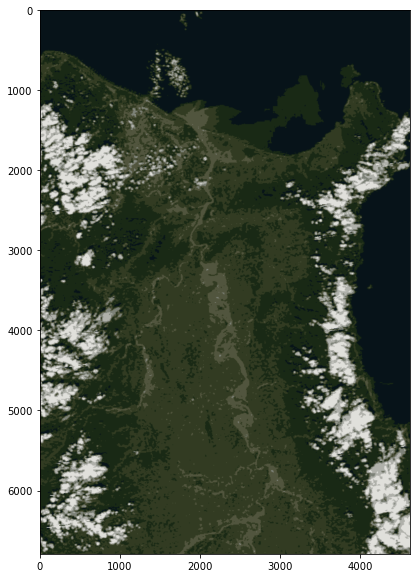

In [57]:
plt.figure(figsize=(10, 10))
plt.imshow(reconst_img)
plt.show()

In [58]:
import joblib
# Saving Clustering Method

joblib.dump(model, os.path.join('.', 'models', 'DayTimeClustering_7Clusters.joblib'))

['.\\models\\DayTimeClustering_7Clusters.joblib']

# NightTime Clustering

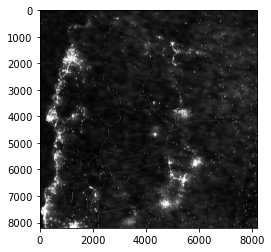

In [28]:
path = r'C:\Users\paolo\OneDrive\Desktop\Projects\laguna-philippines-mapping-fisheries\src\data\Satellite Images\Satellite Images\Night Time\30m-per-pixel\region2_30m_8200\2016\r2-30m-snapshot-2016-11-30T00_00_00Z.tiff'

full_img = cv.imread(path)
full_img = cv.cvtColor(full_img, cv.COLOR_BGR2RGB)

plt.imshow(full_img)
plt.show()

In [35]:
full_img.shape

(8200, 8200, 3)

In [30]:
full_pixels = pd.DataFrame(full_img.reshape(full_img.shape[0] * full_img.shape[1], 3), columns=['R', 'G', 'B'])
full_pixels

,R,G,B
0,26,26,26
1,26,26,26
2,26,26,26
3,26,26,26
4,26,26,26
...,...,...,...
67239995,43,43,43
67239996,43,43,43
67239997,43,43,43
67239998,43,43,43


Done Clustering 2 clusters...
Done Clustering 3 clusters...
Done Clustering 4 clusters...
Done Clustering 5 clusters...
Done Clustering 6 clusters...
Done Clustering 7 clusters...
Done Clustering 8 clusters...
Done Clustering 9 clusters...


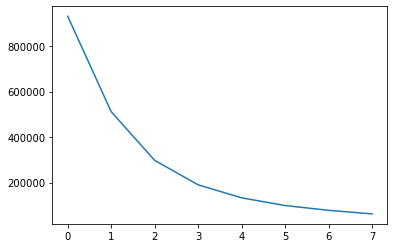

In [31]:
from sklearn.cluster import KMeans

inertias = []
n = 10
for i in range(2, n):
    temp = full_pixels.copy()
    for col in temp.columns:
        temp[col] = temp[col] / 255.
    model = KMeans(n_clusters=i)
    model.fit(temp)
    temp['clusters'] = model.predict(temp)
    inertias.append(model.inertia_)
    print(f'Done Clustering {i} clusters...')

plt.plot(inertias)
plt.show()

In [39]:
temp = full_pixels.copy()
for col in temp.columns:
    temp[col] = temp[col] / 255.
model = KMeans(n_clusters=3)
model.fit(temp)
temp['clusters'] = model.predict(temp)
inertias.append(model.inertia_)
print(f'Done Clustering {i} clusters...')

Done Clustering 8 clusters...


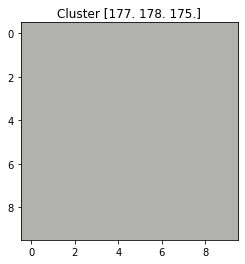

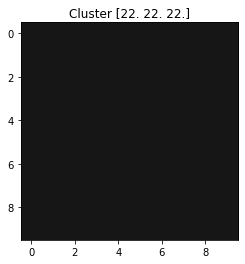

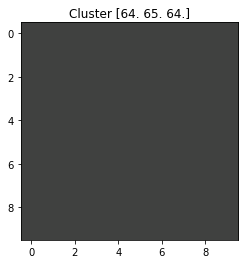

In [40]:
colors = temp.groupby('clusters').mean()

for i, colorvals in colors.iterrows():
    pixel = np.round(colorvals.values * 255.)
    color_img = np.array([pixel for i in range(0, 100)]).reshape(10, 10, 3).astype(int)
    plt.imshow(color_img)
    plt.title(f"Cluster {pixel}")
    plt.show()

In [41]:
pixels = temp.join(temp.groupby('clusters').mean(), on='clusters', lsuffix='O', rsuffix='M')[['RM', 'GM', 'BM']]
reconst_img = pixels.to_numpy().reshape(8200, 8200, 3)

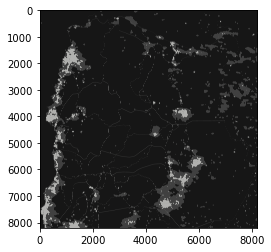

In [42]:
plt.imshow(reconst_img)
plt.show()

In [43]:
import joblib
# Saving Clustering Method

joblib.dump(model, os.path.join('.', 'models', 'NightTimeClustering_3Clusters.joblib'))

['.\\models\\NightTimeClustering_3Clusters.joblib']